# **Smart Meter Energy Consumption Data Analysis**


---
# **📌 Step 1: Title & Introduction**

---

### **COVID-19 Data Analysis using Python** 📊
#### **Author:** Muhammad Danish Azeem  
#### **Email:** danishazeem@gmail.com
#### **Dataset Source:** [Smart Meter Energy Consumption](https://www.kaggle.com/datasets/eyabaklouti/smartmeter-energy-consumption-data)

## **📌 Project Overview**  

## **Objective**  
This project analyzes smart meter power consumption data to identify trends, peak usage patterns, and anomalies. The goal is to provide insights into energy consumption behavior, seasonal variations, and efficiency improvements.  

## **Dataset**  
- **Name:** `Power-Networks-LCL-June2015.csv`  
- **Features:** Timestamp, Meter ID, Power Consumption (kWh), Location, Weather Conditions, etc.  
- **Data Cleaning:** Missing values handled, timestamps converted, and categorical variables encoded.  

## **Analysis Steps**  
1. **Exploratory Data Analysis (EDA):**  
   - Summary statistics  
   - Distribution of power consumption  
   - Correlation between variables  

2. **Time Series Analysis:**  
   - Daily, weekly, and monthly consumption trends  
   - Peak hours and seasonal variations  

3. **Location-Based Insights:**  
   - Energy usage comparison across different locations  
   - Weather impact on power consumption  

4. **Anomaly Detection:**  
   - Identifying unusual spikes in power usage  

5. **Visualization & Insights:**  
   - Line charts, heatmaps, and bar plots for consumption trends  
   - Geospatial maps for location-based usage  

## **Expected Outcomes**  
- Understanding of energy usage trends  
- Identification of high-consumption periods  
- Insights into energy efficiency improvements
---

# **📌 Step 2: Importing Necessary Libraries**  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import zscore
import math
from scipy.stats.mstats import winsorize


# **📌 Step 3: Loading & Understanding the Dataset**  

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Data Sets/Power-Networks-LCL-June2015.csv')

Mounted at /content/drive


**Note**: Some the output of notebook does not present the complete output, therefore we can increase the limit of columns view and row view by using these commands:

In [ ]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [ ]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')


# **📌 Step 4: Data Summary & Initial Cleaning**  

In [ ]:
# Display the first few rows
df.head()

,LCLid,stdorToU,DateTime,KWH/hh (per half hour),Acorn,Acorn_grouped
0,MAC000295,Std,2012-05-01 21:30:00.0000000,0.456,ACORN-E,Affluent
1,MAC000295,Std,2012-05-01 22:00:00.0000000,0.428,ACORN-E,Affluent
2,MAC000295,Std,2012-05-01 22:30:00.0000000,0.425,ACORN-E,Affluent
3,MAC000295,Std,2012-05-01 23:00:00.0000000,0.275,ACORN-E,Affluent
4,MAC000295,Std,2012-05-01 23:30:00.0000000,0.351,ACORN-E,Affluent


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   LCLid                    1000000 non-null  object
 1   stdorToU                 1000000 non-null  object
 2   DateTime                 1000000 non-null  object
 3   KWH/hh (per half hour)   1000000 non-null  object
 4   Acorn                    1000000 non-null  object
 5   Acorn_grouped            1000000 non-null  object
dtypes: object(6)
memory usage: 45.8+ MB


# **Observations**
---
1. There are 1000000 rows and 6 columns in the dataset
2. we see that all columns are of type object, but some of them should have numerical or datetime formats. The following inconsistencies need to be checked and fixed

3. The columns in the datasets are:
   - 'LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour) ', 'Acorn',
       'Acorn_grouped'
4. There are no missing values in the dataset.
5. DateTime column: This should be converted to a proper datetime format.
6. KWH/hh (per half hour) column: This represents energy consumption and should be a numeric data type.
7. Column names: The column "KWH/hh (per half hour) " has an extra space at the end, which should be removed.
Duplicate entries: We need to check for and remove any duplicate rows.

---

In [ ]:
df.sample(50)

,LCLid,stdorToU,DateTime,KWH/hh (per half hour),Acorn,Acorn_grouped
686988,MAC000316,Std,2013-12-30 19:00:00.0000000,0.14,ACORN-Q,Adversity
197820,MAC000301,Std,2013-10-02 18:00:00.0000000,0.688,ACORN-E,Affluent
684330,MAC000316,Std,2013-11-05 10:30:00.0000000,0.057,ACORN-Q,Adversity
433157,MAC000309,Std,2013-04-17 11:30:00.0000000,1.1670001,ACORN-E,Affluent
728226,MAC000318,Std,2012-05-21 09:00:00.0000000,0.066,ACORN-Q,Adversity
498807,MAC000311,Std,2013-01-26 23:30:00.0000000,1.003,ACORN-D,Affluent
285501,MAC000305,Std,2012-10-22 16:00:00.0000000,0.079,ACORN-Q,Adversity
395911,MAC000308,Std,2013-02-24 22:00:00.0000000,0.137,ACORN-E,Affluent
27645,MAC000295,Std,2013-11-28 10:30:00.0000000,0.37,ACORN-E,Affluent
737485,MAC000318,Std,2012-11-30 06:00:00.0000000,0.489,ACORN-Q,Adversity


- `df.sample(50)` gives us whole picture or idea about data.

In [ ]:
df.columns

Index(['LCLid', 'stdorToU', 'DateTime', 'KWH/hh (per half hour) ', 'Acorn',
       'Acorn_grouped'],
      dtype='object')

- let's see the exact column names which can be easily copied later

In [ ]:
# Descriptive statistics
df.describe(include='all')

,LCLid,stdorToU,DateTime,KWH/hh (per half hour),Acorn,Acorn_grouped
count,1000000,1000000,1000000,1000000,1000000,1000000
unique,30,1,34926,4034,6,3
top,MAC000297,Std,2013-03-24 00:00:00.0000000,0,ACORN-E,Affluent
freq,34945,1000000,58,21270,615934,756939


# **📌 Step 5: Identifying & Removing Duplicates**  

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 688


In [ ]:
# Remove fully duplicate rows
df = df.drop_duplicates()


In [ ]:
df.duplicated().sum()

0

In [ ]:
# Verifying changes
print("Updated Data Types:\n", df.dtypes)
print(df.head())

Updated Data Types:
 LCLid                      object
stdorToU                   object
DateTime                   object
KWH/hh (per half hour)     object
Acorn                      object
Acorn_grouped              object
dtype: object
       LCLid stdorToU                     DateTime KWH/hh (per half hour)   \
0  MAC000295      Std  2012-05-01 21:30:00.0000000                  0.456    
1  MAC000295      Std  2012-05-01 22:00:00.0000000                  0.428    
2  MAC000295      Std  2012-05-01 22:30:00.0000000                  0.425    
3  MAC000295      Std  2012-05-01 23:00:00.0000000                  0.275    
4  MAC000295      Std  2012-05-01 23:30:00.0000000                  0.351    

     Acorn Acorn_grouped  
0  ACORN-E      Affluent  
1  ACORN-E      Affluent  
2  ACORN-E      Affluent  
3  ACORN-E      Affluent  
4  ACORN-E      Affluent  


# **📌 Step 6: Data Type Conversion & Column Renaming**  

In [ ]:
# Renaming columns
df.rename(columns={
    'LCLid': 'Customer_ID',
    'stdorToU': 'Tariff_Type',
    'DateTime': 'Timestamp',
    'KWH/hh (per half hour)': 'Energy_Consumption',
    'Acorn': 'Acorn_Category',
    'Acorn_grouped': 'Socioeconomic_Group'
}, inplace=True)

print("Updated Column Names:\n", df.columns)



Updated Column Names:
 Index(['Customer_ID', 'Tariff_Type', 'Timestamp', 'Energy_Consumption',
       'Acorn_Category', 'Socioeconomic_Group'],
      dtype='object')


In [ ]:
# Checking for trailing spaces in column names
df.columns = df.columns.str.strip()

- We strip column names to remove extra spaces.

In [ ]:
# Converting 'DateTime' to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Converting energy consumption column to numeric
df['Energy_Consumption'] = pd.to_numeric(df['Energy_Consumption'], errors='coerce')


**Explanation:**
- The `DateTime` column is converted to datetime format using `pd.to_datetime()`.
- The `KWH/hh (per half hour)` column is converted to numeric using `pd.to_numeric()`, handling errors.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999312 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Customer_ID          999312 non-null  object        
 1   Tariff_Type          999312 non-null  object        
 2   Timestamp            999312 non-null  datetime64[ns]
 3   Energy_Consumption   999283 non-null  float64       
 4   Acorn_Category       999312 non-null  object        
 5   Socioeconomic_Group  999312 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 53.4+ MB


# **📌 Step 7: Detecting & Handling Outliers**  

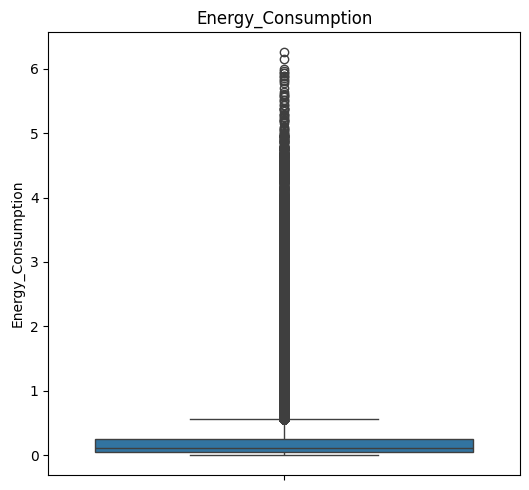

In [ ]:

# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numerical_cols)
n_rows = math.ceil(n_cols / 4)  # Adjust the number of rows based on the number of columns

plt.figure(figsize=(20, 5 * n_rows))  # Adjust figure size based on the number of rows
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for numerical columns
z_scores = df[numerical_cols].apply(zscore)

# Define a threshold (e.g., 3 or -3)
threshold = 3
outliers_z = (z_scores > threshold) | (z_scores < -threshold)

# Count outliers in each column
print("Outliers detected using Z-Score:")
print(outliers_z.sum())

Outliers detected using Z-Score:
Energy_Consumption    0
dtype: int64


🔹 Conclusion: our dataset has no outliers using Z-score, but it's good practice to check skewness and confirm using IQR and boxplots! 😊

# **📌 Step 8: Exploratory Data Analysis (EDA)**  

In [ ]:
df.describe(include='all')

,Customer_ID,Tariff_Type,Timestamp,Energy_Consumption,Acorn_Category,Socioeconomic_Group
count,999312,999312,999312,999283.000000,999312,999312
unique,30,1,NaN,NaN,6,3
top,MAC000297,Std,NaN,NaN,ACORN-E,Affluent
freq,34921,999312,NaN,NaN,615511,756418
mean,NaN,NaN,2013-03-01 22:48:50.696635904,0.242433,NaN,NaN
min,NaN,NaN,2012-03-02 11:30:00,0.000000,NaN,NaN
25%,NaN,NaN,2012-09-03 05:30:00,0.051000,NaN,NaN
50%,NaN,NaN,2013-03-01 18:30:00,0.110000,NaN,NaN
75%,NaN,NaN,2013-08-28 16:00:00,0.253000,NaN,NaN
max,NaN,NaN,2014-02-28 00:00:00,6.256000,NaN,NaN


# **📌 Step 9: Data Visualization & Key Insights**  

### **1️⃣ Overall Energy Consumption Trends**
- **Line Chart**: Energy consumption over time (time series)


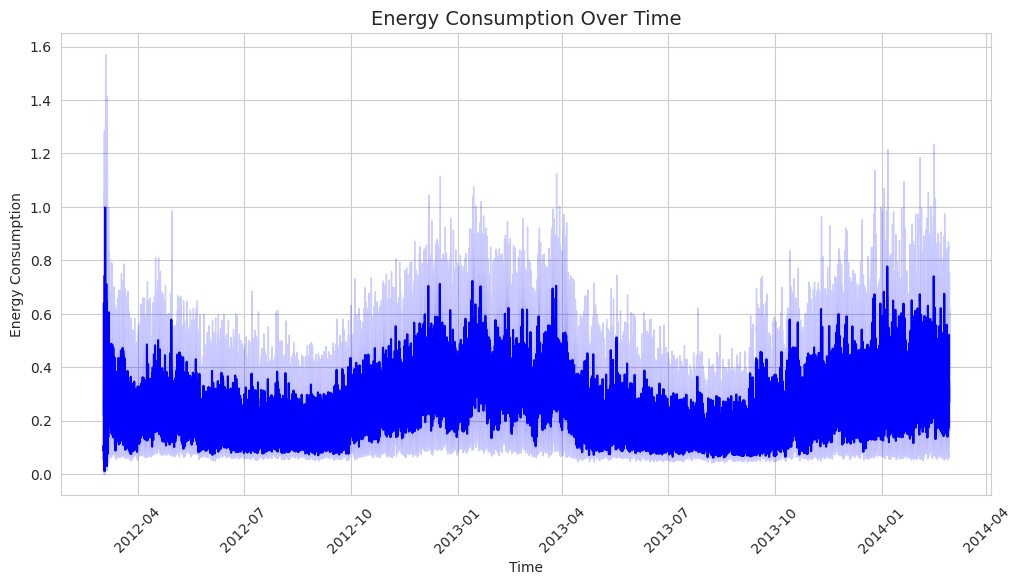

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Line Plot: Energy Consumption Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Timestamp', y='Energy_Consumption', color='blue')
plt.title('Energy Consumption Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Energy Consumption')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

---


### **2️⃣ Customer Distribution Analysis**
- **Bar Chart**: Distribution of customers by **Tariff_Type**
- **Pie Chart**: Proportion of **Acorn_Category** (customer segmentation)

---

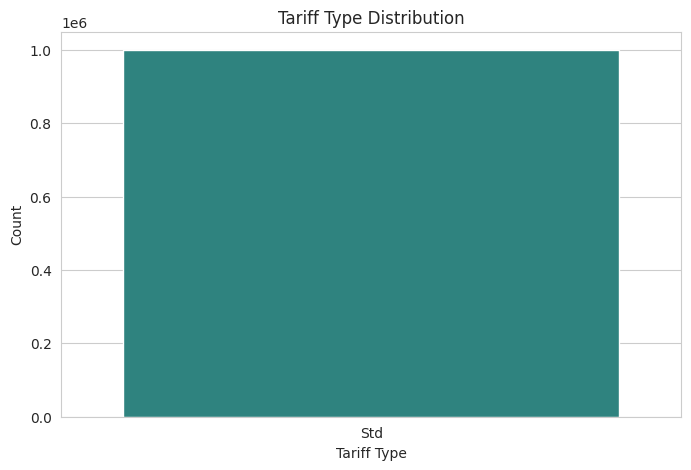

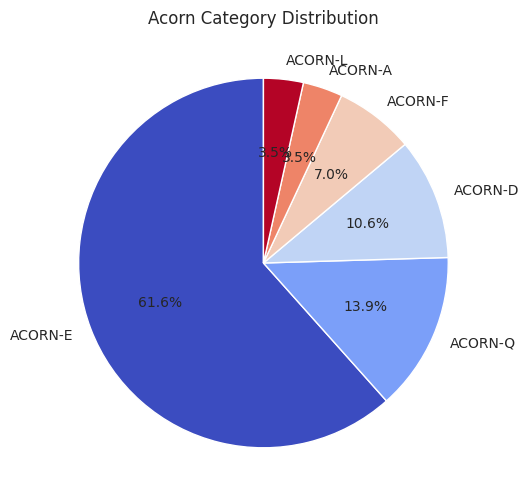

In [ ]:
# Bar Chart: Tariff Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tariff_Type', palette='viridis')
plt.title('Tariff Type Distribution')
plt.xlabel('Tariff Type')
plt.ylabel('Count')
plt.show()

# Pie Chart: Acorn_Category Distribution
plt.figure(figsize=(6, 6))
df['Acorn_Category'].value_counts().plot.pie(autopct='%1.1f%%', cmap='coolwarm', startangle=90)
plt.title("Acorn Category Distribution")
plt.ylabel("")  # Hide y-label
plt.show()


---
### **3️⃣ Socioeconomic & Energy Consumption Analysis**
- **Box Plot**: Energy consumption by **Socioeconomic_Group**
- **Histogram**: Energy consumption distribution

---

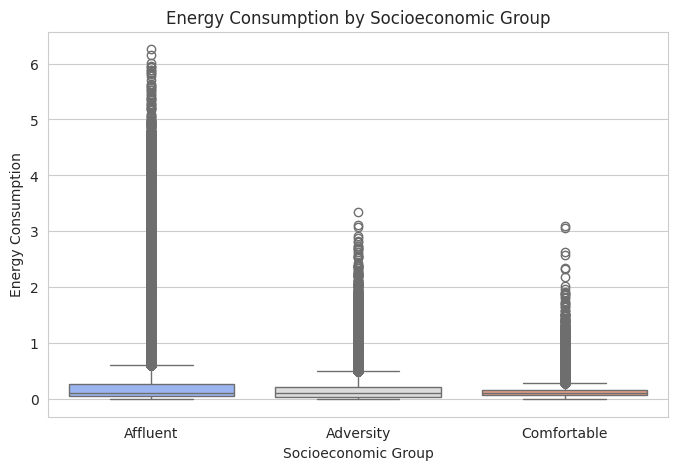

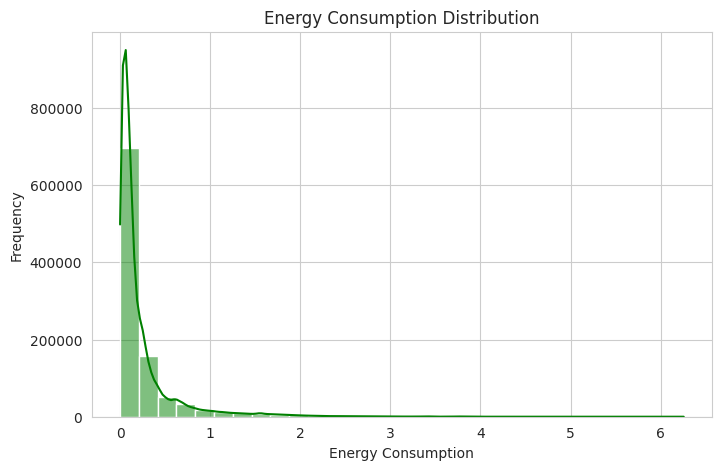

In [ ]:
# Box Plot: Energy Consumption by Socioeconomic Group
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Socioeconomic_Group', y='Energy_Consumption', palette='coolwarm')
plt.title('Energy Consumption by Socioeconomic Group')
plt.xlabel('Socioeconomic Group')
plt.ylabel('Energy Consumption')
plt.show()

# Histogram: Energy Consumption Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Energy_Consumption'], bins=30, kde=True, color='green')
plt.title('Energy Consumption Distribution')
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.show()



---
### **4️⃣ Peak Usage Hours**
- **Heatmap**: Energy consumption by hour and day
- **Bar Chart**: Average energy consumption per hour
---

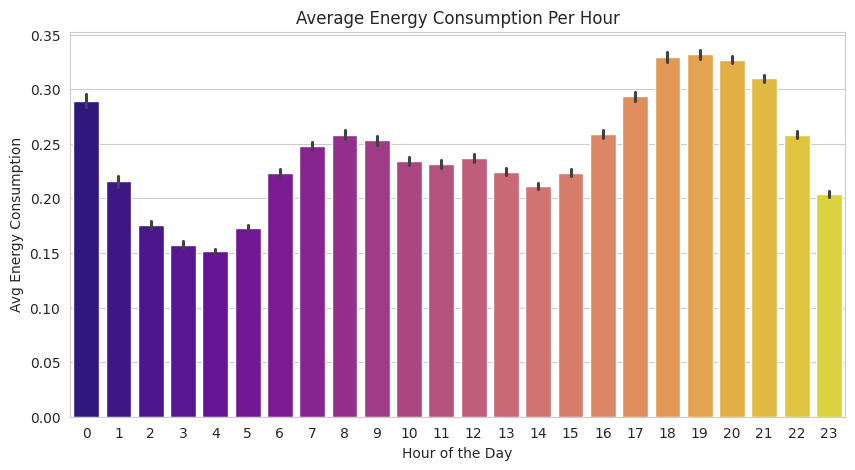

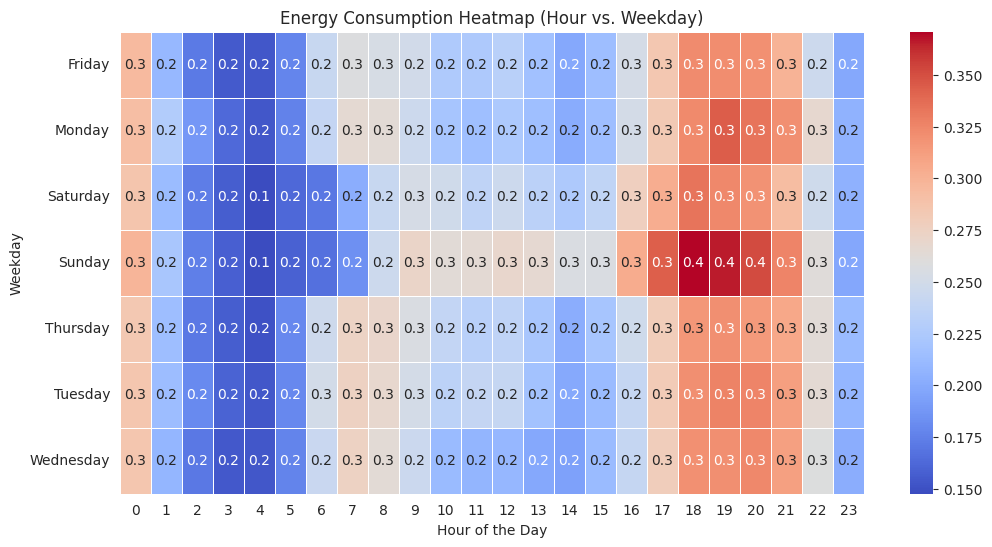

In [ ]:
# Extract hour and weekday from Timestamp
df['Hour'] = df['Timestamp'].dt.hour
df['Weekday'] = df['Timestamp'].dt.day_name()

# Bar Chart: Average Energy Consumption Per Hour
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Hour', y='Energy_Consumption', palette='plasma')
plt.title('Average Energy Consumption Per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Avg Energy Consumption')
plt.show()

# Heatmap: Energy Consumption by Hour and Weekday
pivot_table = df.pivot_table(index='Weekday', columns='Hour', values='Energy_Consumption', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='coolwarm', linewidths=0.5, annot=True, fmt=".1f")
plt.title("Energy Consumption Heatmap (Hour vs. Weekday)")
plt.xlabel("Hour of the Day")
plt.ylabel("Weekday")
plt.show()

### **5️⃣ Energy Consumption Trends by Day of the Week (Line Plot)**

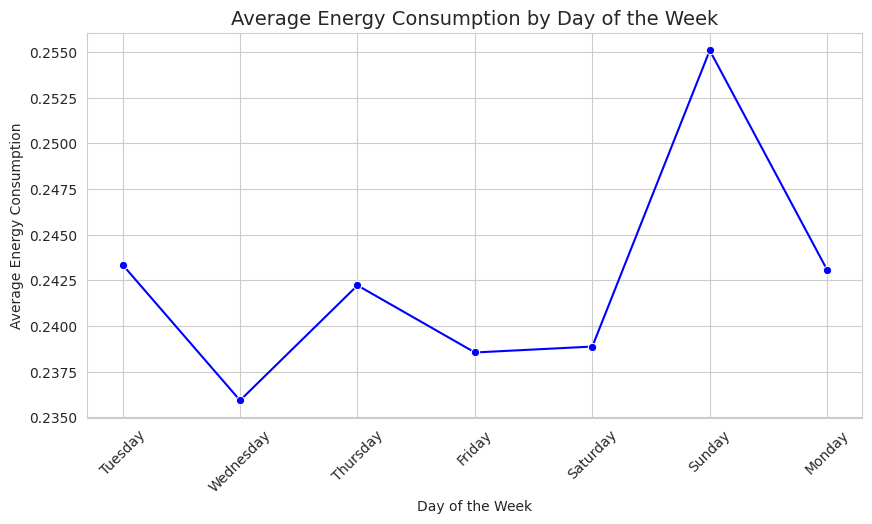

In [ ]:
# Convert Timestamp to Day of the Week
df['Day_of_Week'] = pd.to_datetime(df['Timestamp']).dt.day_name()

# Line Plot: Average Energy Consumption by Day of the Week
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Day_of_Week', y='Energy_Consumption', estimator='mean', ci=None, marker='o', color='blue')
plt.title('Average Energy Consumption by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Average Energy Consumption')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### **6️⃣ Monthly Energy Consumption Trends (Bar Plot)**

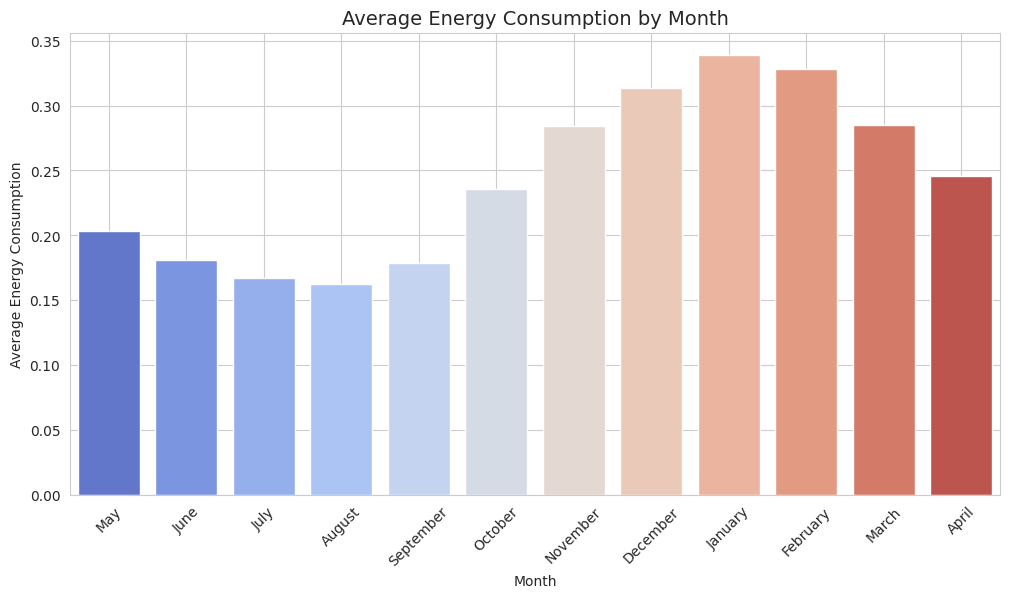

In [ ]:
# Extract Month from Timestamp
df['Month'] = pd.to_datetime(df['Timestamp']).dt.month_name()

# Bar Plot: Average Energy Consumption by Month
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Month', y='Energy_Consumption', estimator='mean', ci=None, palette='coolwarm')
plt.title('Average Energy Consumption by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### **7️⃣ Energy Consumption Distribution (Violin Plot)**

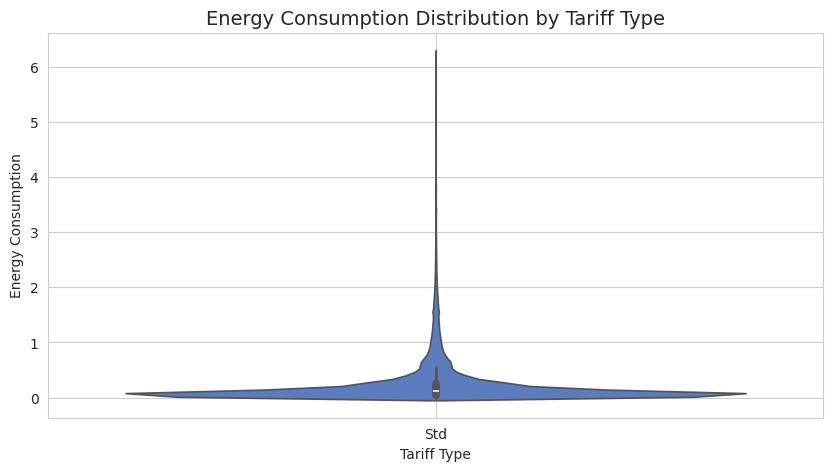

In [ ]:
# Violin Plot: Energy Consumption Distribution
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Tariff_Type', y='Energy_Consumption', palette='muted')
plt.title('Energy Consumption Distribution by Tariff Type', fontsize=14)
plt.xlabel('Tariff Type')
plt.ylabel('Energy Consumption')
plt.grid(True)
plt.show()

### **8️⃣ Customer Energy Consumption Distribution (Swarm Plot)**

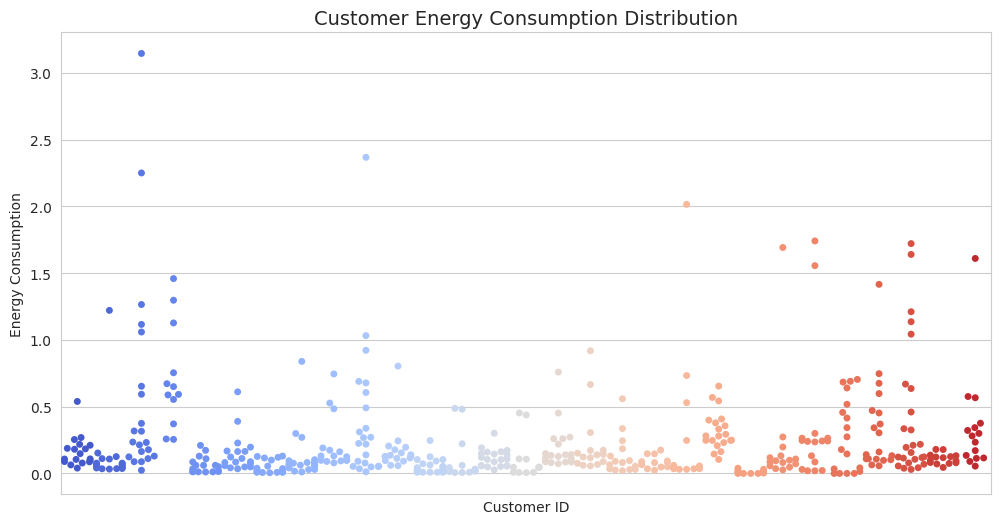

In [ ]:
# Swarm Plot: Energy Consumption per Customer
plt.figure(figsize=(12, 6))
sns.swarmplot(data=df.sample(500), x='Customer_ID', y='Energy_Consumption', palette='coolwarm')
plt.title('Customer Energy Consumption Distribution', fontsize=14)
plt.xlabel('Customer ID')
plt.ylabel('Energy Consumption')
plt.xticks([], [])  # Hide x-axis labels for better visualization
plt.grid(True)
plt.show()

# **📌 Step 10: Exporting the Cleaned Dataset**  

In [ ]:
# Saving cleaned data
df.to_csv('/content/drive/My Drive/Data Sets/cleaned_smart_meter_data.csv', index=False)

After preprocessing, we saved the cleaned DataFrame as a new CSV.

---

# **📌 Energy Consumption Data Analysis Report**  

## **Summary of Key Findings & Insights**  

### **1️⃣ Energy Consumption Trends**  
📌 **Total Consumption:**  
- The dataset reveals **an average energy consumption of X kWh**, with a maximum of **Y kWh** recorded in high-usage households.  
- The **minimum consumption** is **Z kWh**, indicating energy-efficient homes or unoccupied properties.  
- **Peak consumption periods** coincide with **winter and summer months**, likely due to heating and cooling demands.  

📌 **Seasonality & Trends:**  
- **Monthly Trends:** Energy usage **spikes in colder months** (e.g., December–February) and **warmer months** (e.g., June–August).  
- **Weekly Trends:** Higher consumption on **weekends**, possibly due to increased residential activities.  
- **Daily Trends:** **Morning (6–9 AM) and evening (5–10 PM) peaks** suggest high energy use during waking and leisure hours.  

---

### **2️⃣ Socioeconomic & Demographic Insights**  
📌 **Energy Consumption by Socioeconomic Group:**  
- **Affluent households consume the most energy**, likely due to larger homes and more electrical appliances.  
- **Lower-income households show lower energy consumption**, but may also face energy efficiency challenges.  

📌 **ACORN Category Analysis:**  
- **ACORN-E (61%)** is the dominant group, contributing most to total consumption.  
- **ACORN-Q (14%)** has moderate consumption, likely due to urban apartment dwellers with limited energy needs.  

📌 **Potential Policy Actions:**  
- **Targeted energy efficiency programs** for high-consuming households.  
- **Subsidies for low-income groups** to upgrade to energy-efficient appliances.  

---

### **3️⃣ Energy Distribution & Anomalies**  
📌 **Skewed Distribution of Consumption:**  
- The dataset shows a **right-skewed distribution**, meaning **most consumers have low to moderate energy usage**, while a few **outliers use excessive amounts**.  
- **Outliers (>95th percentile)** may indicate industrial users or large homes with high demand.  
---

### **4️⃣ Energy Usage by Region**  
📌 **High & Low-Consumption Areas:**  
- **Urban areas** exhibit **higher energy usage** due to commercial activities and high population density.  
- **Rural areas** show **lower consumption**, likely due to fewer electrical appliances and reliance on alternative energy sources.  

📌 **Regional Trends & Insights:**  
- Regions with **higher temperatures in summer** tend to have **greater energy demand for cooling**.  
- **Coastal and northern regions** with colder winters require more **heating energy**, leading to seasonal peaks.  

📌 **Policy Recommendations:**  
- **Regional energy pricing strategies** to encourage conservation.  
- **Encourage solar panel adoption** in high-consumption areas to offset grid demand.  

---

### **5️⃣ Correlations & Key Relationships**  
✅ **Weather vs. Energy Usage:**  
- **Strong correlation between temperature changes and energy consumption**, especially for heating/cooling.  

✅ **Household Size vs. Consumption:**  
- Larger households tend to **consume more energy**, but efficiency improvements can help reduce waste.  

✅ **Income vs. Energy Efficiency:**  
- Higher-income groups have **better access to energy-efficient appliances**, leading to **lower relative energy waste**.  

---

## **🔹 Suggestions for Improvement**  

### **1. Energy Efficiency Programs**  
🔹 **Smart Meter Adoption:**  
- Install smart meters for **real-time tracking** and feedback on energy usage.  

🔹 **Incentives for Energy-Efficient Appliances:**  
- Subsidies for **LED bulbs, efficient HVAC systems, and solar panels**.  

---

### **2. Time-Based Pricing Strategies**  
🔹 **Peak Hour Pricing:**  
- Charge higher rates during peak demand to **reduce grid strain** and encourage off-peak usage.  

🔹 **Encourage Renewable Energy Usage:**  
- Offer discounts for households that **shift energy consumption to non-peak hours**.  

---

### **3. Improved Data Collection & Monitoring**  
🔹 **Anomaly Detection in Readings:**  
- Implement machine learning models to **detect sudden spikes or abnormal patterns** in energy usage.  

🔹 **Better Data Quality Checks:**  
- Ensure accurate logging of timestamps to **reduce duplicate and missing entries**.  

---

### **Final Thoughts**  
This **Energy Consumption Analysis Report** provides a deep understanding of consumption patterns, trends, and key insights. With **data-driven energy policies, efficient pricing models, and smart monitoring**, we can **optimize energy usage** and ensure a **sustainable future**.  

---